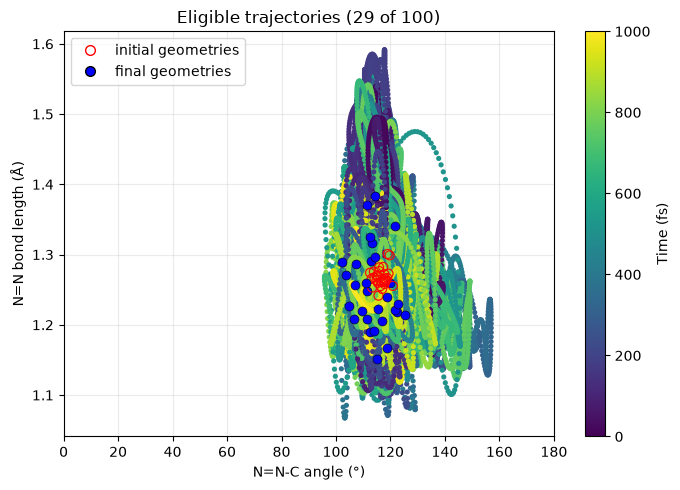

In [1]:
from pathlib import Path
import math
import re
import warnings

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Run from either the repository root or sharc/.
SEARCH_ROOT = Path("sharc") if Path("sharc").is_dir() else Path(".")
TRAJ_GLOB = "structure_0006/traj-allmols/**/TRAJ_*"
DIHEDRAL_ATOMS = (4, 5, 6, 7)
NNC_ANGLE_ATOMS = (5, 6, 7)
NN_BOND_ATOMS = (5, 6)
CIS_TRANS_THRESHOLD_DEG = 90.0
GROUND_MCH_STATE = 1
NN_BOND_MIN_ANGSTROM = 0.9
NN_BOND_EXCLUSION_ANGSTROM = 3.0


def parse_xyz_lines(lines, source):
    frames, pos = [], 0
    while pos < len(lines):
        while pos < len(lines) and not lines[pos].strip():
            pos += 1
        if pos == len(lines):
            break
        try:
            natoms = int(lines[pos].strip())
        except ValueError as error:
            raise ValueError(f"{source}: expected atom count at line {pos + 1}") from error
        if natoms <= 0 or pos + natoms + 1 >= len(lines):
            raise ValueError(f"{source}: incomplete or invalid XYZ frame")
        symbols, xyz = [], []
        for line_number, line in enumerate(lines[pos + 2 : pos + 2 + natoms], pos + 3):
            fields = line.split()
            if len(fields) < 4:
                raise ValueError(f"{source}: malformed atom record at line {line_number}")
            try:
                xyz.append([float(value) for value in fields[1:4]])
            except ValueError as error:
                raise ValueError(f"{source}: non-numeric coordinate at line {line_number}") from error
            symbols.append(fields[0])
        frames.append((symbols, np.asarray(xyz, dtype=float)))
        pos += natoms + 2
    if not frames:
        raise ValueError(f"{source}: no XYZ frames")
    return frames


def frame_times_fs(lines, source):
    times, pos = [], 0
    while pos < len(lines):
        while pos < len(lines) and not lines[pos].strip():
            pos += 1
        if pos == len(lines):
            break
        try:
            natoms = int(lines[pos].strip())
        except ValueError as error:
            raise ValueError(f"{source}: expected atom count at line {pos + 1}") from error
        if pos + natoms + 1 >= len(lines):
            raise ValueError(f"{source}: incomplete or invalid XYZ frame")
        match = re.search(r"\bt=\s*([-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?)", lines[pos + 1])
        if not match:
            raise ValueError(f"{source}: missing time in frame comment at line {pos + 2}")
        times.append(float(match.group(1)))
        pos += natoms + 2
    return np.asarray(times, dtype=float)


def bond_length_angstrom(coordinates, atom_indices):
    indices = np.asarray(atom_indices, dtype=int) - 1
    if len(indices) != 2 or np.any(indices < 0) or np.any(indices >= len(coordinates)):
        raise ValueError(f"invalid atom indices {tuple(atom_indices)} for {len(coordinates)} atoms")
    return float(np.linalg.norm(coordinates[indices[0]] - coordinates[indices[1]]))


def nnc_angle_deg(coordinates):
    indices = np.asarray(NNC_ANGLE_ATOMS, dtype=int) - 1
    if np.any(indices < 0) or np.any(indices >= len(coordinates)):
        raise ValueError(f"invalid atom indices {NNC_ANGLE_ATOMS} for {len(coordinates)} atoms")
    first, vertex, third = coordinates[indices]
    first_vector, third_vector = first - vertex, third - vertex
    denominator = np.linalg.norm(first_vector) * np.linalg.norm(third_vector)
    if denominator == 0:
        raise ValueError("N=N-C angle is undefined for a zero-length bond")
    cosine = np.clip(np.dot(first_vector, third_vector) / denominator, -1.0, 1.0)
    return float(math.degrees(math.acos(cosine)))


def signed_dihedral_deg(coordinates):
    indices = np.asarray(DIHEDRAL_ATOMS, dtype=int) - 1
    p0, p1, p2, p3 = coordinates[indices]
    b0, b1, b2 = -(p1 - p0), p2 - p1, p3 - p2
    b1_norm = np.linalg.norm(b1)
    if b1_norm == 0:
        raise ValueError("middle dihedral bond has zero length")
    b1 /= b1_norm
    v, w = b0 - np.dot(b0, b1) * b1, b2 - np.dot(b2, b1) * b1
    if np.linalg.norm(v) == 0 or np.linalg.norm(w) == 0:
        raise ValueError("dihedral is undefined for collinear atoms")
    angle = math.degrees(math.atan2(np.dot(np.cross(b1, v), w), np.dot(v, w)))
    return ((angle + 180.0) % 360.0) - 180.0


def final_mch_state(lis_path):
    rows = [line.split() for line in lis_path.read_text(encoding="utf-8").splitlines()
            if line.strip() and not line.lstrip().startswith("#")]
    if not rows or len(rows[-1]) < 4:
        raise ValueError(f"{lis_path}: no valid output.lis data row")
    try:
        return int(rows[-1][3])
    except ValueError as error:
        raise ValueError(f"{lis_path}: invalid final MCH state") from error


def is_eligible(frames, lis_path):
    bond_lengths = [bond_length_angstrom(coordinates, NN_BOND_ATOMS) for _, coordinates in frames]
    if min(bond_lengths) < NN_BOND_MIN_ANGSTROM or max(bond_lengths) > NN_BOND_EXCLUSION_ANGSTROM:
        return False
    return final_mch_state(lis_path) == GROUND_MCH_STATE


trajectory_dirs = sorted(path for path in SEARCH_ROOT.glob(TRAJ_GLOB) if path.is_dir())
if not trajectory_dirs:
    raise FileNotFoundError(f"No trajectory folders found under {SEARCH_ROOT}/{TRAJ_GLOB}")

trajectory_data = []
for trajectory_dir in trajectory_dirs:
    xyz_path, lis_path = trajectory_dir / "output.xyz", trajectory_dir / "output.lis"
    try:
        if not xyz_path.is_file() or xyz_path.stat().st_size == 0:
            raise ValueError("missing or empty output.xyz")
        if not lis_path.is_file() or lis_path.stat().st_size == 0:
            raise ValueError("missing or empty output.lis")
        lines = xyz_path.read_text(encoding="utf-8").splitlines()
        frames = parse_xyz_lines(lines, str(xyz_path))
        times_fs = frame_times_fs(lines, str(xyz_path))
        if len(frames) != len(times_fs):
            raise ValueError("frame/time count mismatch")
        if not is_eligible(frames, lis_path):
            continue
        nnc_angles_deg = np.asarray([nnc_angle_deg(coordinates) for _, coordinates in frames])
        nn_bond_lengths_angstrom = np.asarray([bond_length_angstrom(coordinates, NN_BOND_ATOMS) for _, coordinates in frames])
        trajectory_data.append((times_fs, nnc_angles_deg, nn_bond_lengths_angstrom))
    except (OSError, UnicodeDecodeError, ValueError) as error:
        warnings.warn(f"Skipped {trajectory_dir}: {error}")

if not trajectory_data:
    raise ValueError("No eligible trajectories found")

all_times = np.concatenate([times_fs for times_fs, _, _ in trajectory_data])
time_norm = plt.Normalize(all_times.min(), all_times.max())
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 5))
for times_fs, nnc_angles_deg, nn_bond_lengths_angstrom in trajectory_data:
    ax.scatter(nnc_angles_deg, nn_bond_lengths_angstrom, c=times_fs, cmap=cmap, norm=time_norm,
               s=14, edgecolors="none", zorder=2)
    ax.scatter(nnc_angles_deg[0], nn_bond_lengths_angstrom[0], facecolors="none", edgecolors="red",
               s=42, linewidths=0.8, zorder=3)
    ax.scatter(nnc_angles_deg[-1], nn_bond_lengths_angstrom[-1], color="blue", edgecolors="black",
               s=42, linewidths=0.4, zorder=3)

colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap=cmap), ax=ax)
colorbar.set_label("Time (fs)")
ax.set(xlabel="N=N-C angle (°)", ylabel="N=N bond length (Å)", xlim=(0, 180))
ax.set_title(f"Eligible trajectories ({len(trajectory_data)} of {len(trajectory_dirs)})")
ax.grid(alpha=0.25)
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor="red", markersize=7, label="initial geometries"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="blue", markeredgecolor="black", markersize=7, label="final geometries"),
], loc="best")
fig.tight_layout()
plt.show()
